# Project 3 Milestone 2
## Migraine Type Classification

In [82]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

In [83]:
# Open the file

migraine_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DSC 680/migraine_symptom_classification.csv", 
    low_memory=False
)

In [84]:
# display column names for easy reference

print(migraine_df.columns)

Index(['Age', 'Duration', 'Frequency', 'Location', 'Character', 'Intensity',
       'Nausea', 'Vomit', 'Phonophobia', 'Photophobia', 'Visual', 'Sensory',
       'Dysphasia', 'Dysarthria', 'Vertigo', 'Tinnitus', 'Hypoacusis',
       'Diplopia', 'Defect', 'Ataxia', 'Conscience', 'Paresthesia', 'DPF',
       'Type'],
      dtype='object')


In [85]:
migraine_df.head()

,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Vertigo,Tinnitus,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Type
0,30,1,5,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
1,50,3,5,1,1,3,1,1,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
2,53,2,1,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
3,45,3,5,1,1,3,1,0,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
4,53,1,1,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,1,Typical aura with migraine


### Visualizations

In [87]:
migraine_df.info() 
migraine_df.describe() 
migraine_df.isnull().sum()

# 400 rows and 24 columns
# no missing values
# all numeric except the target

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          400 non-null    int64 
 1   Duration     400 non-null    int64 
 2   Frequency    400 non-null    int64 
 3   Location     400 non-null    int64 
 4   Character    400 non-null    int64 
 5   Intensity    400 non-null    int64 
 6   Nausea       400 non-null    int64 
 7   Vomit        400 non-null    int64 
 8   Phonophobia  400 non-null    int64 
 9   Photophobia  400 non-null    int64 
 10  Visual       400 non-null    int64 
 11  Sensory      400 non-null    int64 
 12  Dysphasia    400 non-null    int64 
 13  Dysarthria   400 non-null    int64 
 14  Vertigo      400 non-null    int64 
 15  Tinnitus     400 non-null    int64 
 16  Hypoacusis   400 non-null    int64 
 17  Diplopia     400 non-null    int64 
 18  Defect       400 non-null    int64 
 19  Ataxia       400 non-null    

Age            0
Duration       0
Frequency      0
Location       0
Character      0
Intensity      0
Nausea         0
Vomit          0
Phonophobia    0
Photophobia    0
Visual         0
Sensory        0
Dysphasia      0
Dysarthria     0
Vertigo        0
Tinnitus       0
Hypoacusis     0
Diplopia       0
Defect         0
Ataxia         0
Conscience     0
Paresthesia    0
DPF            0
Type           0
dtype: int64

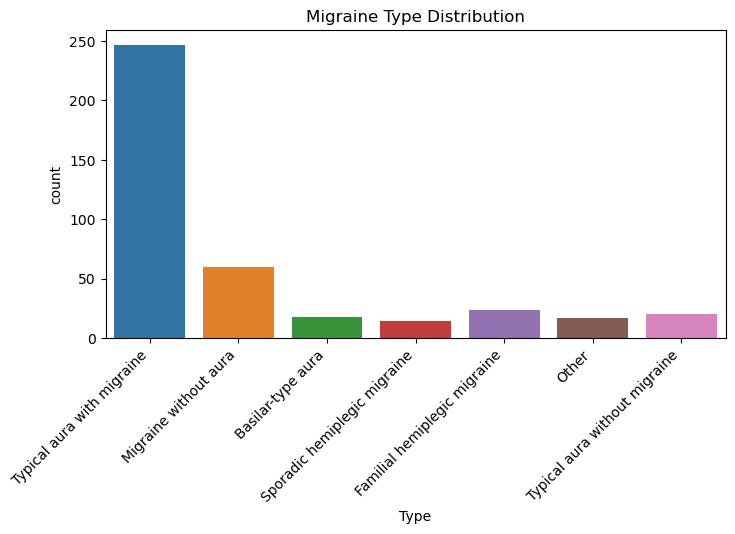

In [88]:
# migraine distribution counts
plt.figure(figsize=(8,4))
sns.countplot(data=migraine_df, x="Type")
plt.xticks(rotation=45, ha="right")
plt.title("Migraine Type Distribution")
plt.show()

In [89]:
migraine_df["Type"].value_counts()

Typical aura with migraine       247
Migraine without aura             60
Familial hemiplegic migraine      24
Typical aura without migraine     20
Basilar-type aura                 18
Other                             17
Sporadic hemiplegic migraine      14
Name: Type, dtype: int64

### dataset is imbalanced with Typical Aura having 60% of the cases. Will address during modeling.

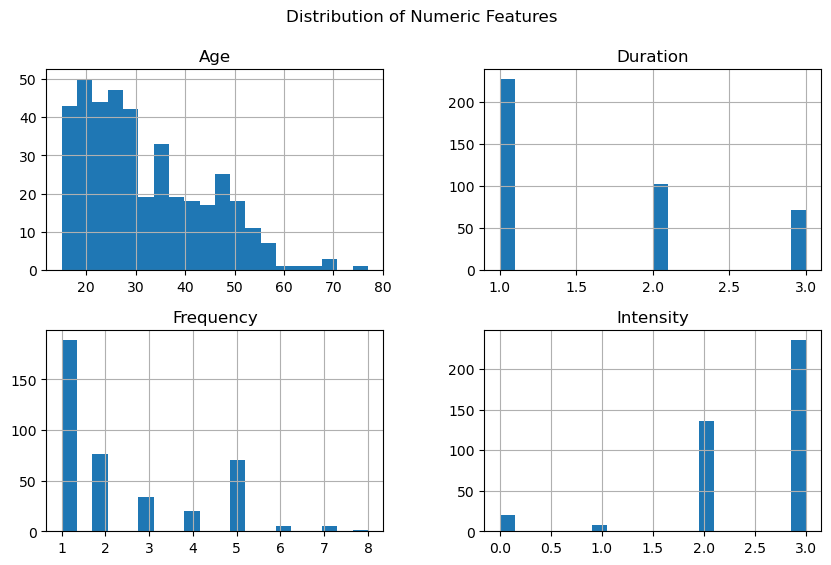

In [91]:
#Histograms for age, Duration, Frequency, and Intensity
numeric_columns = ["Age", "Duration", "Frequency", "Intensity"]
migraine_df[numeric_columns].hist(figsize=(10,6), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.show()

In [92]:
### Age of the participant - most 20-30
### Duration of the migraine attack (in hours) - most 1 hour
### Frequency of attacks over a specific period - 1 most common
### Pain severity on a scale from 1 (mild) to 5 (very severe) - 3 most cmmon

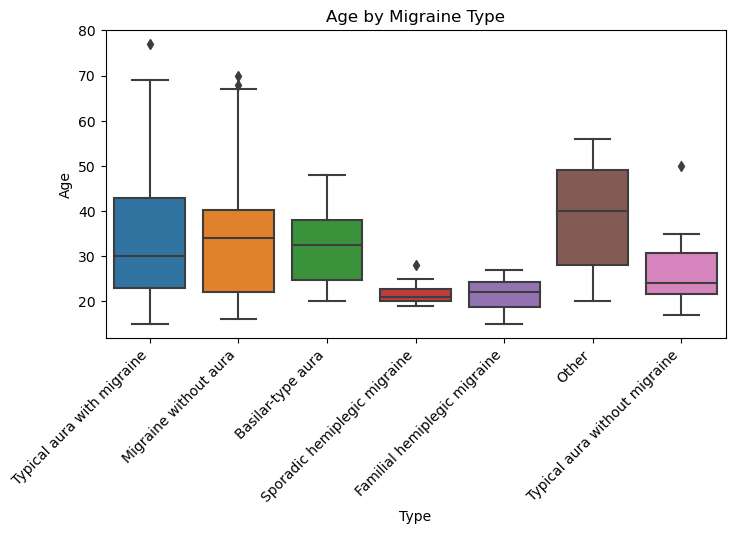

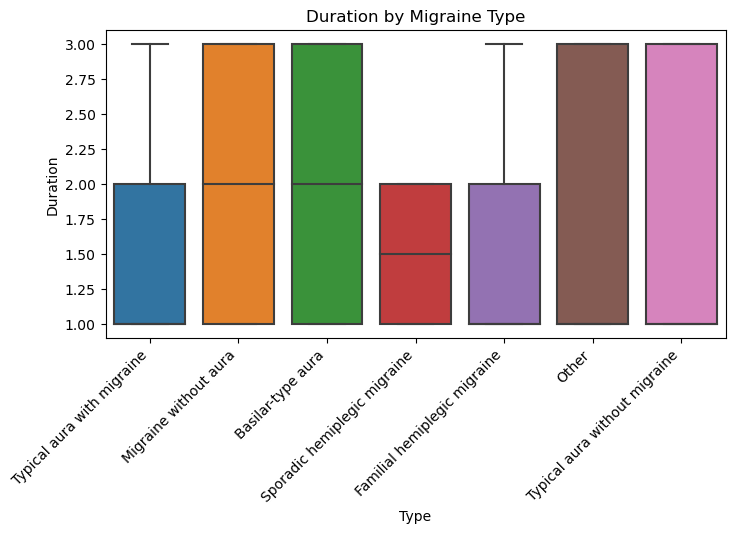

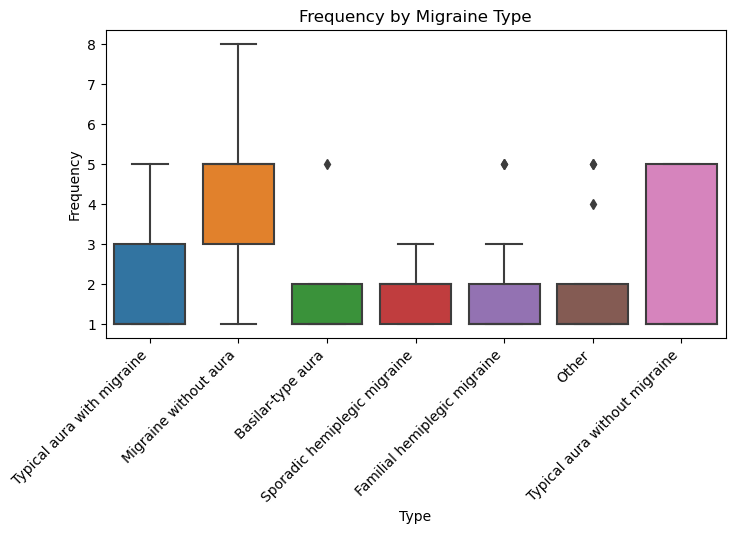

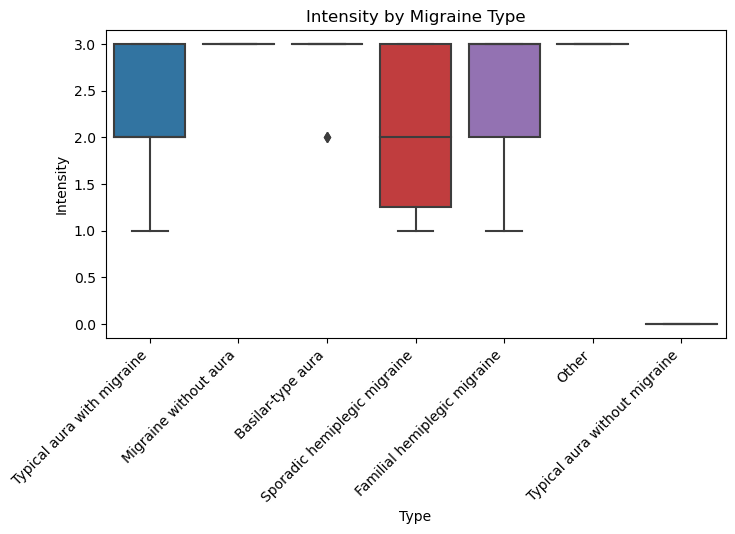

In [93]:
# boxplot for migraine type for the features age, duration, frequency, and severity
for col in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=migraine_df, x="Type", y=col)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{col} by Migraine Type")
    plt.show()

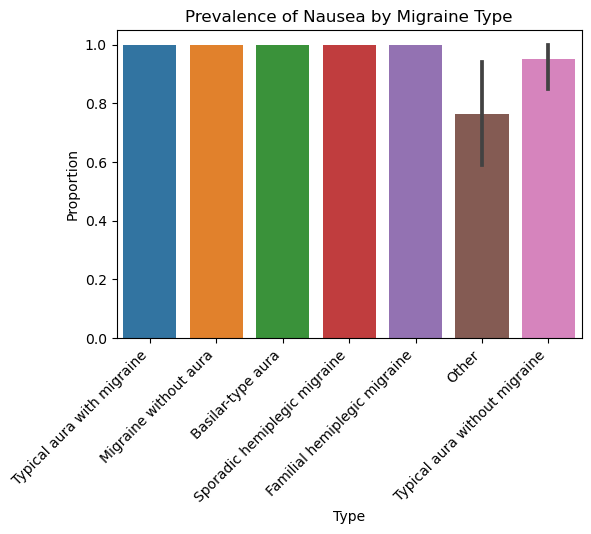

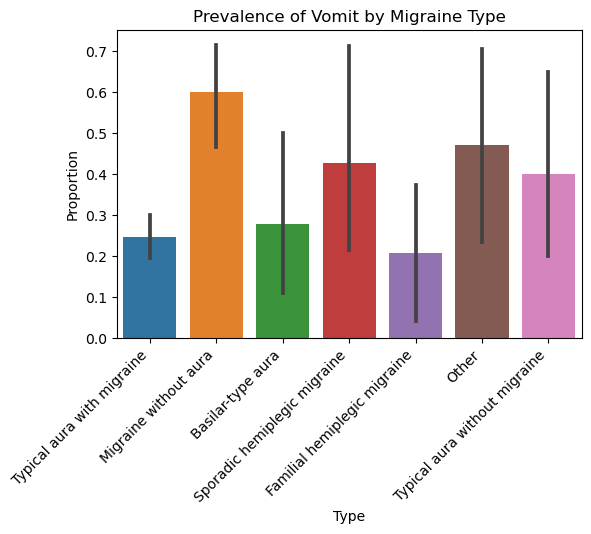

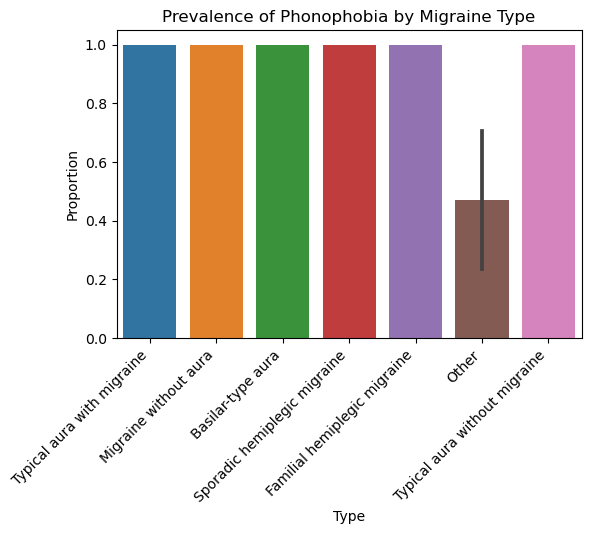

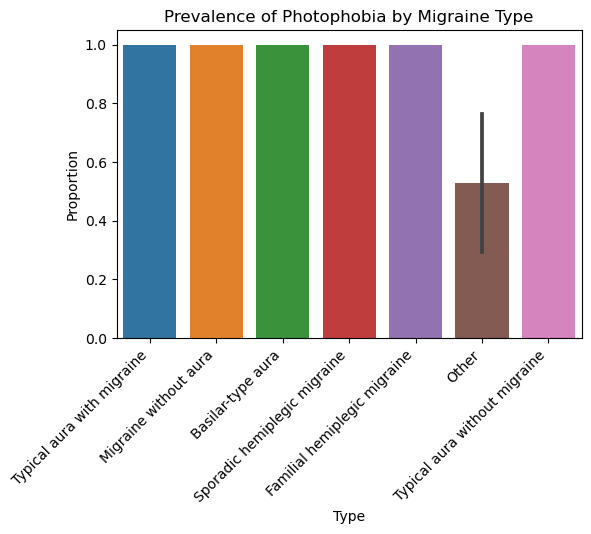

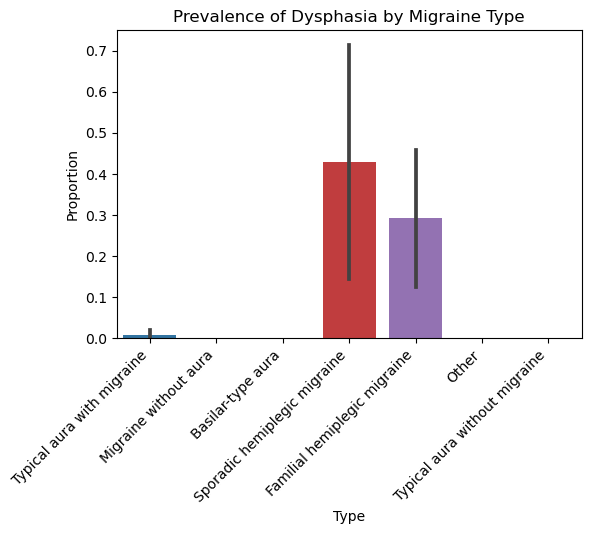

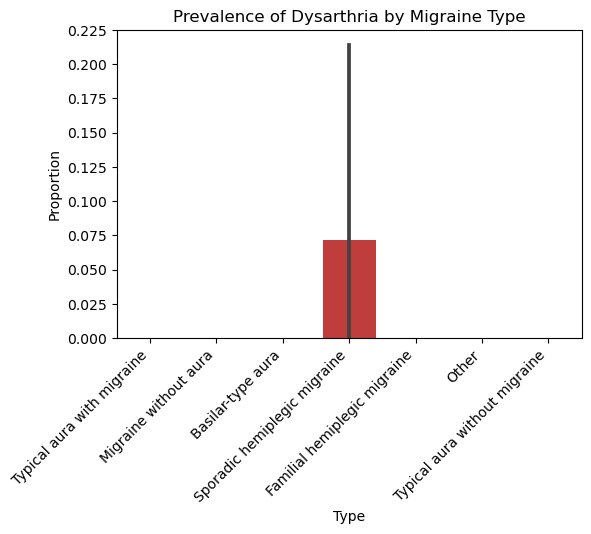

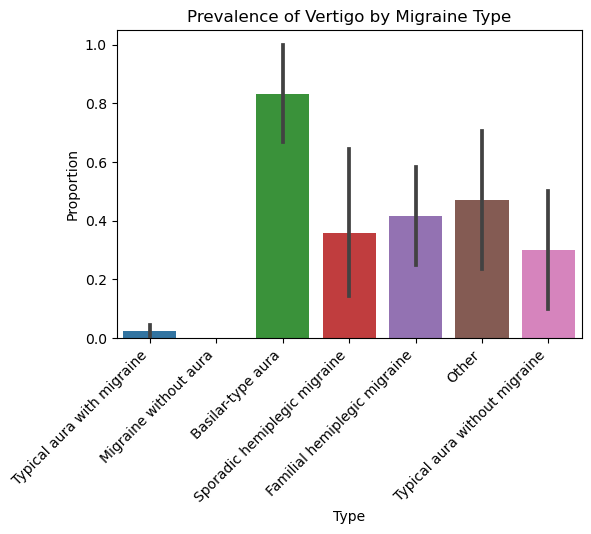

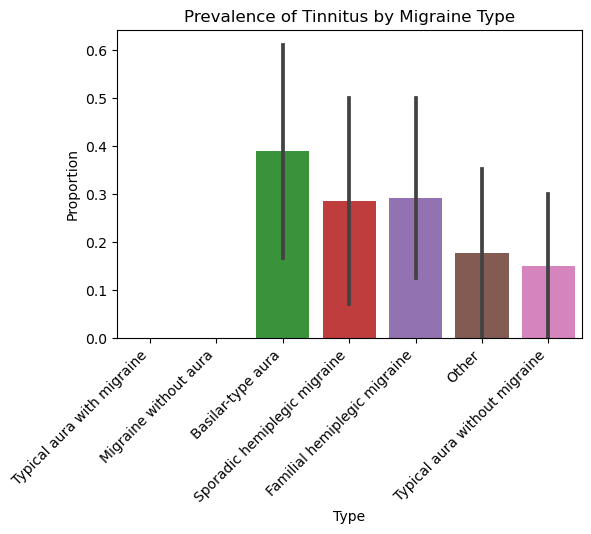

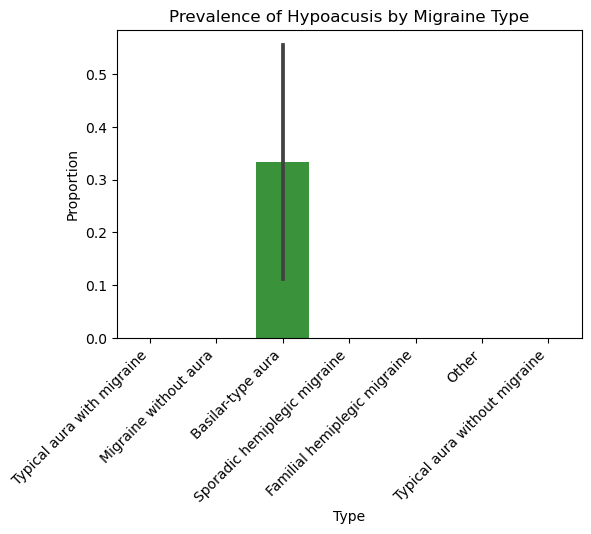

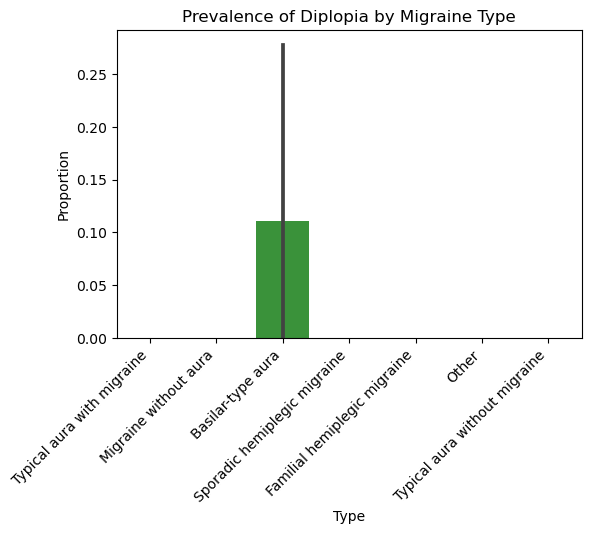

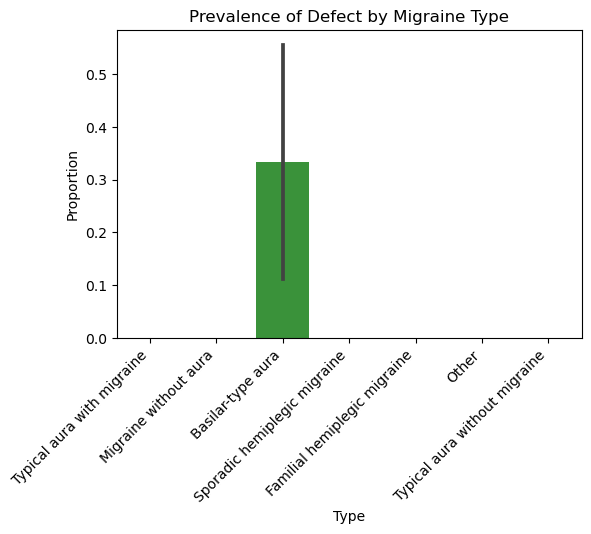

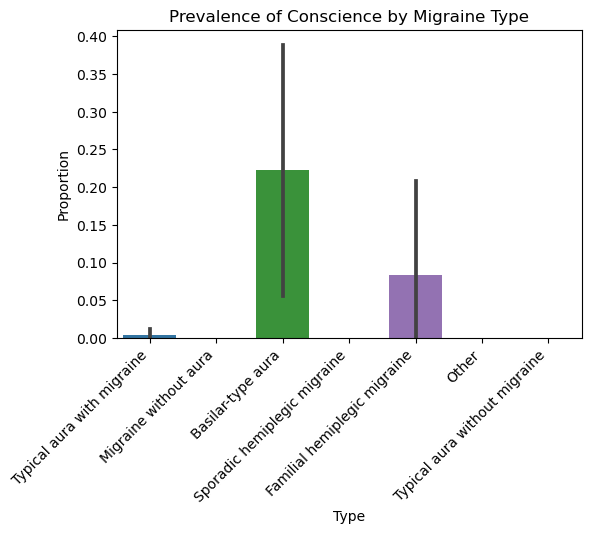

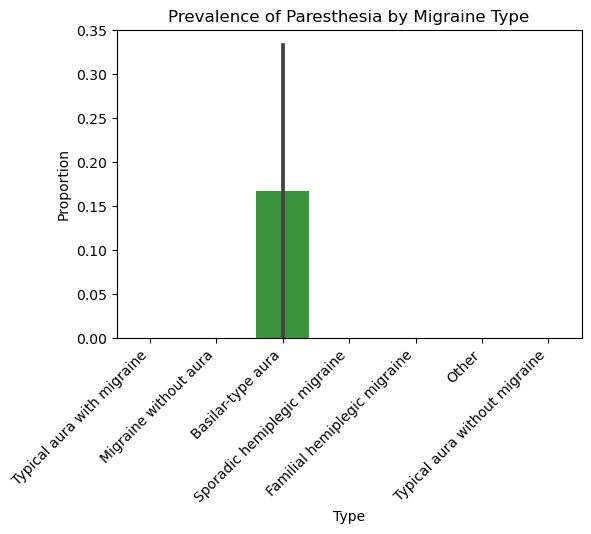

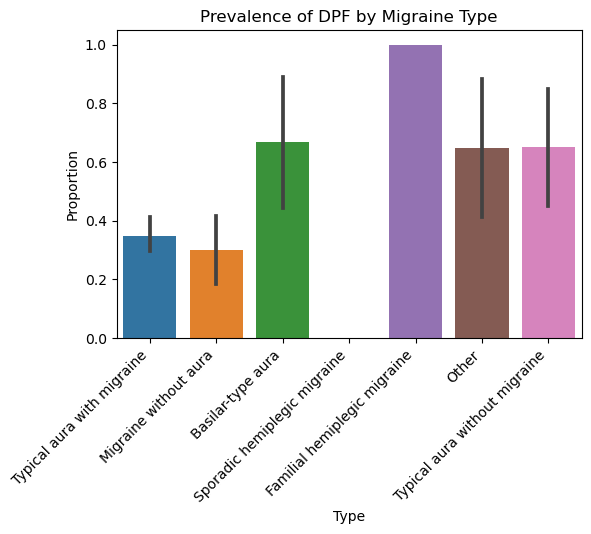

In [94]:
# Symptom prevalence by migraine type
binary_columns = [col for col in migraine_df.columns if migraine_df[col].nunique() == 2]

for col in binary_columns:
    plt.figure(figsize=(6,4))
    sns.barplot(data=migraine_df, x="Type", y=col, estimator=lambda x: sum(x)/len(x))
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Prevalence of {col} by Migraine Type")
    plt.ylabel("Proportion")
    plt.show()

C:\Users\rmtol\AppData\Local\Temp\ipykernel_17536\4156670557.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(migraine_df.corr(), cmap="coolwarm")


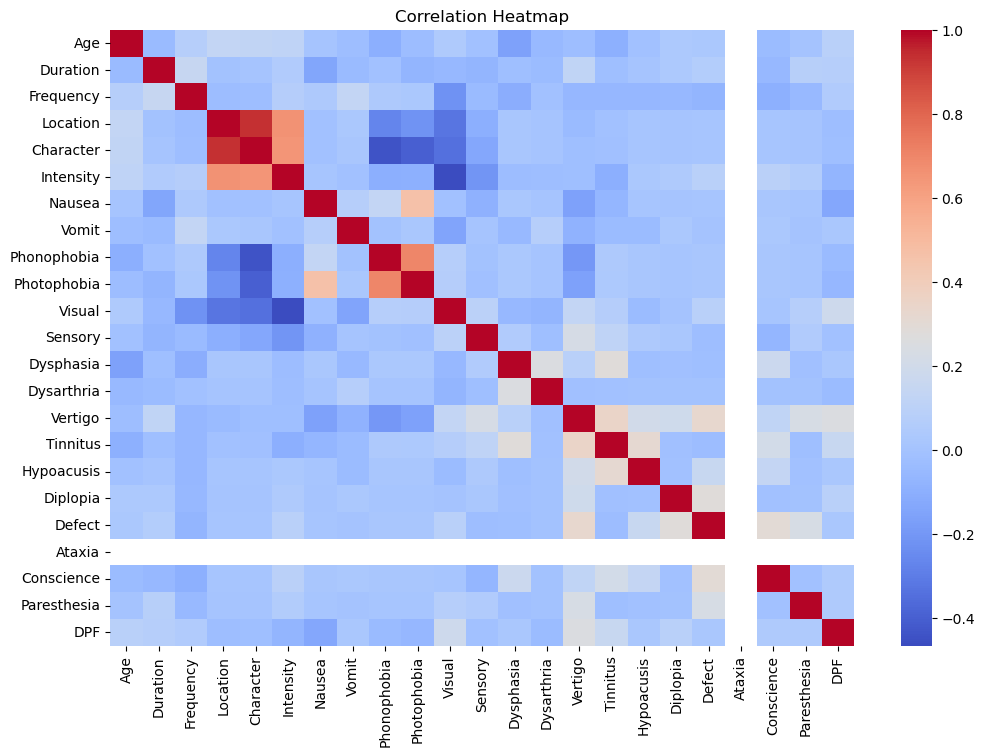

In [95]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(migraine_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### moderate positive correlations between location and intensity, character and intensity, nausea and photophobia, phonophobia and photophobia.
### moderate negative correlations between intensity and visual, phonophobia and character.
### ataxia is likely to be almost always 0 in the data.

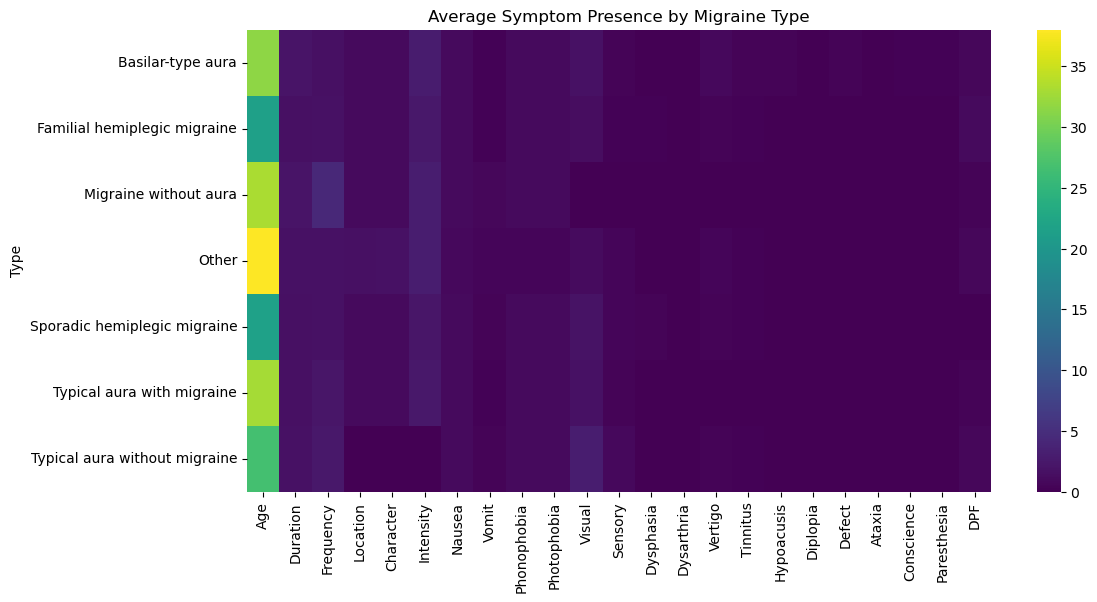

In [97]:
# Symptom count heatmap
symptom_columns = migraine_df.columns.drop(["Type"])

heatmap_data = migraine_df.groupby("Type")[symptom_columns].mean()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Average Symptom Presence by Migraine Type")
plt.show()

### most symptoms are rare across migraine types with low numbers of cases.
### Age has a variation of symptoms.
### People in the “Other” migraine type category tend to be older than the rest.

### Preprocessing
### Creating a stratified train/test split
### Scaling for logistic regression)


In [100]:
from sklearn.model_selection import train_test_split

X = migraine_df.drop("Type", axis=1)
y = migraine_df["Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [101]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((320, 23), (80, 23), (320,), (80,))

In [102]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced"))
])

### Modeling: Logistic Regression and Random Forrest

In [104]:
# training the logistic regression model
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

In [105]:
# baseline model
y_pred = log_reg_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

                               precision    recall  f1-score   support

            Basilar-type aura       1.00      0.75      0.86         4
 Familial hemiplegic migraine       0.29      1.00      0.45         5
        Migraine without aura       0.86      1.00      0.92        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       0.67      0.67      0.67         3
   Typical aura with migraine       0.97      0.73      0.84        49
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.80        80
                    macro avg       0.83      0.83      0.79        80
                 weighted avg       0.91      0.80      0.83        80



### Migraine without aura and Typical aura without migraine perform well, show high precision, high recall, and high F1‑scores.
### Typical aura with migraine performs reasonably well. High precision (0.97), moderate recall (0.73), and strong F1 (0.84).
### Basilar-type aura, Other, and Sporadic hemiplegic migraine struggle with recall. Have good precision and moderate F1.
### Familial hemiplegic migraine recall is 1.00 but precision is low. F1  reflects the imbalance between precision and recall.

In [107]:
# train the Random Forest model with class weights due to imbalanced data

from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report

migraine_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

migraine_rf.fit(X_train, y_train)

y_pred_rf = migraine_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

                               precision    recall  f1-score   support

            Basilar-type aura       0.50      0.25      0.33         4
 Familial hemiplegic migraine       0.57      0.80      0.67         5
        Migraine without aura       0.92      1.00      0.96        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       1.00      0.67      0.80         3
   Typical aura with migraine       0.94      0.96      0.95        49
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.90        80
                    macro avg       0.85      0.76      0.79        80
                 weighted avg       0.90      0.90      0.89        80



### Random Forest improves recall and F1 for most classes, especially those with small sample sizes. 
### Basilar-type aura is a challenge with a precision of 0.50, a recall of 0.25, and an F1 of 0.33.
### The Random Forest achieves an accuracy of 0.90 and a weighted F1 of 0.89, both improvements over logistic regression. The model shows better balance across classes, especially in F1 scores.

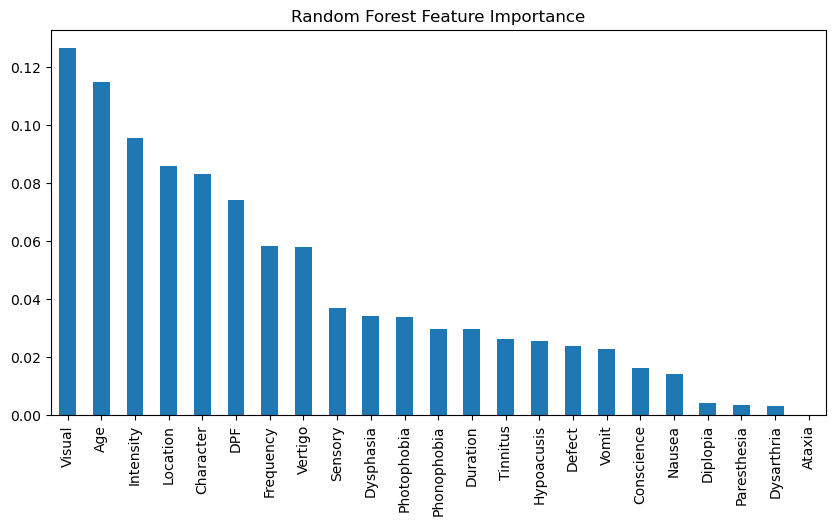

In [109]:
# Random Forest feature importance 
importances = pd.Series(
    migraine_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.plot(kind='bar', figsize=(10,5))
plt.title("Random Forest Feature Importance")
plt.show()

### A gradual decline in feature importance shows the model is not overly dependent on a single feature.

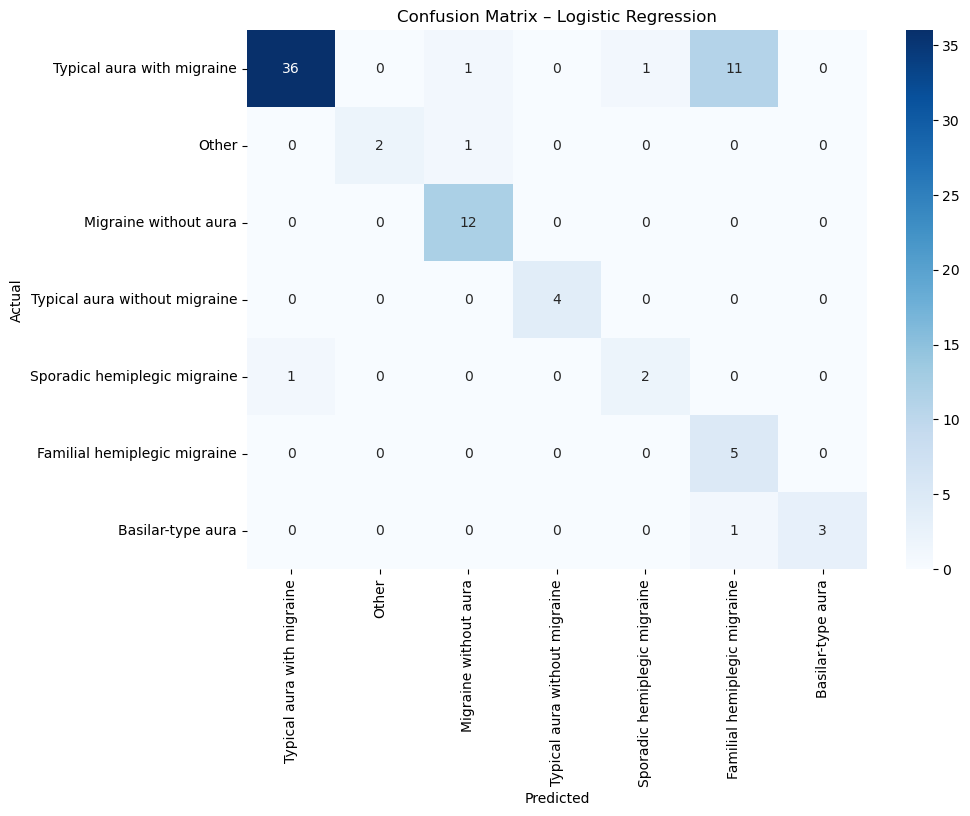

In [111]:
# logisitic regression confusion matrix

from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred, labels=y_train.unique())

plt.figure(figsize=(10,7))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=y_train.unique(),
            yticklabels=y_train.unique())
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

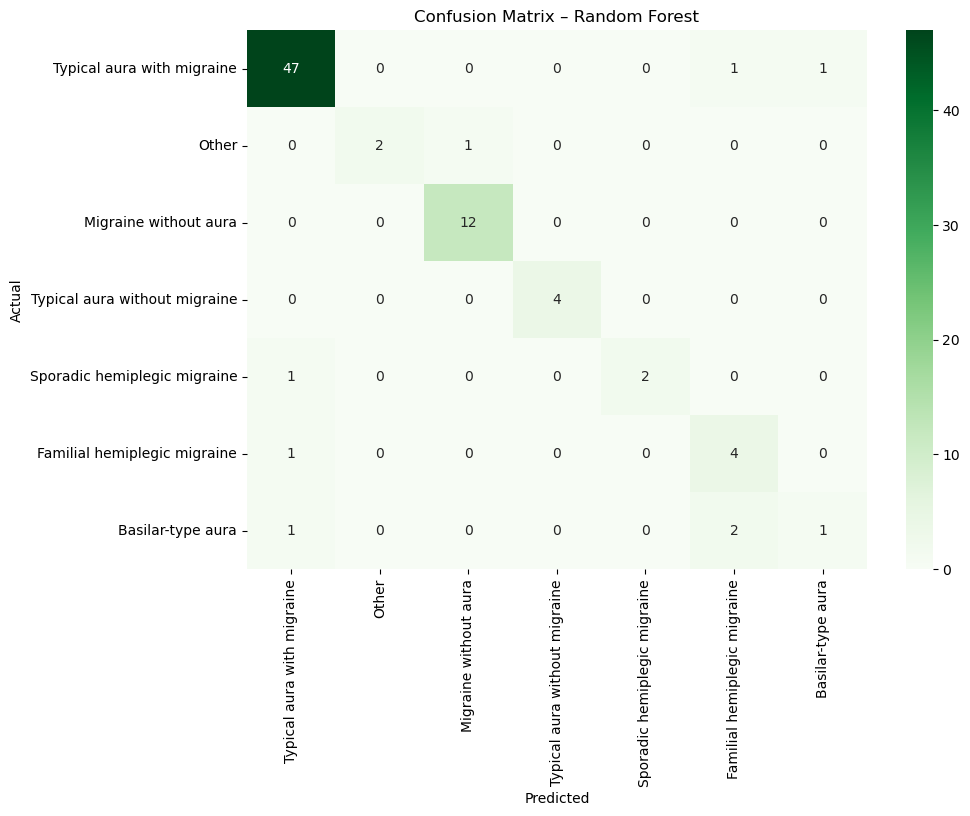

In [112]:
# confusion matrix of random forrest

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=y_train.unique())

plt.figure(figsize=(10,7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=y_train.unique(),
            yticklabels=y_train.unique())
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### The logistic regression model is heavily biased toward predicting Typical aura with migraine, the largest class. Rare cases are barely predicted.
### For random forrest, the diagonal is stronger and more complete (47 correct for Typical aura with migraine, 12 for Migraine without aura). Also shows improvement on rare classes.  
